# Anomaly Detection — Isolation Forest & Statistical Methods

**Anomaly detection** identifies data points that are significantly different from the majority of the data — without requiring labeled examples of anomalies.

---

## Table of Contents
1. [What is Anomaly Detection?](#1-what)
2. [Types of Anomalies](#2-types)
3. [Statistical Methods](#3-statistical)
   - Z-Score
   - IQR
   - Mahalanobis Distance
4. [Isolation Forest — Core Idea](#4-isolation-forest-idea)
5. [Isolation Forest — The Math](#5-isolation-forest-math)
6. [Hyperparameters](#6-hyperparameters)
7. [One-Class SVM](#7-one-class-svm)
8. [Evaluating Anomaly Detectors](#8-evaluation)
9. [Full Implementation and Comparison](#9-implementation)
10. [When to Use Which Method](#10-guide)

---
## 1. What is Anomaly Detection?

Unlike supervised classification, anomaly detection is mostly **unsupervised** (or semi-supervised): the algorithm learns what "normal" looks like from the data, then flags deviations.

### Key Real-World Applications

| Domain | Application | Normal | Anomalous |
|---|---|---|---|
| Finance | Fraud detection | Regular purchases | Stolen-card spending |
| Cybersecurity | Intrusion detection | Normal traffic | Port scans, DDoS |
| Manufacturing | Predictive maintenance | Stable sensor readings | Pre-failure vibrations |
| Healthcare | Patient monitoring | Stable vitals | Sudden deterioration |
| E-commerce | Bot detection | Human browsing | Automated scraping |

### Supervised vs Unsupervised Anomaly Detection

- **Unsupervised**: No labels at all — pure novelty/outlier detection
- **Semi-supervised**: Only normal examples during training (novelty detection)
- **Supervised**: Labeled anomalies exist — becomes a classification problem

---
## 2. Types of Anomalies

### Point Anomalies
A single data point that is unusual compared to the rest.

**Example**: A transaction of \$50,000 when all others are under \$500.

### Contextual Anomalies (Conditional)
A point is anomalous **in a specific context** but not globally.

**Example**: 30°C is normal in summer, anomalous in winter. Buying 500 ski jackets is normal for a ski shop in November, anomalous in July.

### Collective Anomalies
A **group** of data points is anomalous together, even if each is individually normal.

**Example**: 50 transactions of \$9.99 in 10 minutes — each individually fine, but the pattern is suspicious (card testing attack).

---
## 3. Statistical Methods

### 3.1 Z-Score

For a feature with mean $\mu$ and standard deviation $\sigma$:

$$z = \frac{x - \mu}{\sigma}$$

A point is an outlier if $|z| > 3$ (more than 3 standard deviations from the mean).

**Assumption**: Data follows a normal distribution.

**Problem**: Outliers inflate $\mu$ and $\sigma$, making the method less sensitive. Use **Modified Z-Score** instead:

$$z_{\text{mod}} = \frac{0.6745(x_i - \text{median})}{\text{MAD}}$$

where $\text{MAD} = \text{median}(|x_i - \text{median}|)$. Flag if $|z_{\text{mod}}| > 3.5$.

### 3.2 IQR Method

$$\text{IQR} = Q_3 - Q_1$$

Outlier bounds:
- Lower: $Q_1 - 1.5 \times \text{IQR}$
- Upper: $Q_3 + 1.5 \times \text{IQR}$

**Why IQR?** Robust — uses percentiles, not sensitive to the outliers themselves.

For extreme outliers, use $3 \times \text{IQR}$ instead of $1.5 \times \text{IQR}$.

### 3.3 Mahalanobis Distance

For multivariate data, Euclidean distance ignores correlations between features and scale differences. **Mahalanobis distance** fixes both:

$$D_M(\mathbf{x}) = \sqrt{(\mathbf{x} - \boldsymbol{\mu})^T \Sigma^{-1} (\mathbf{x} - \boldsymbol{\mu})}$$

where $\Sigma^{-1}$ is the inverse covariance matrix.

**Statistical test**: Under multivariate normality, $D_M^2 \sim \chi^2_p$ where $p$ = number of features. A point is an outlier if:

$$D_M^2(\mathbf{x}) > \chi^2_{p,\, 0.975}$$

Use **Minimum Covariance Determinant (MCD)** estimator instead of the sample covariance for robustness — MCD finds the $h$-subset of points whose covariance matrix has the smallest determinant, making it resistant to the outliers themselves.

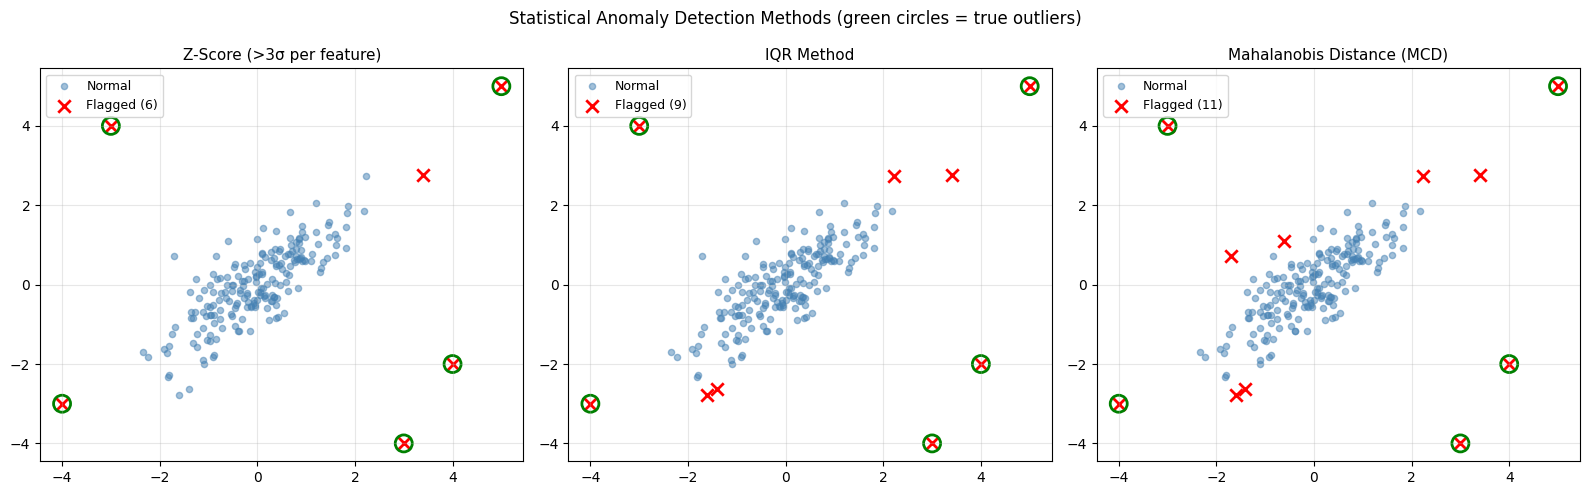

Z-Score        : flagged=  6, precision=0.83, recall=1.00
IQR            : flagged=  9, precision=0.56, recall=1.00
Mahalanobis    : flagged= 11, precision=0.45, recall=1.00


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2
from sklearn.covariance import MinCovDet, EmpiricalCovariance

np.random.seed(42)

# Generate normal data + outliers
n_normal = 200
X_normal = np.random.multivariate_normal([0, 0], [[1, 0.8], [0.8, 1]], n_normal)
X_outliers = np.array([[4, -2], [-3, 4], [5, 5], [-4, -3], [3, -4]])
X = np.vstack([X_normal, X_outliers])
y_true = np.array([0]*n_normal + [1]*len(X_outliers))

# 1. Z-Score (per feature)
mu, sigma = X.mean(axis=0), X.std(axis=0)
z_scores = np.abs((X - mu) / sigma)
z_outliers = (z_scores > 3).any(axis=1)

# 2. IQR (per feature)
Q1, Q3 = np.percentile(X, 25, axis=0), np.percentile(X, 75, axis=0)
IQR = Q3 - Q1
iqr_outliers = ((X < Q1 - 1.5*IQR) | (X > Q3 + 1.5*IQR)).any(axis=1)

# 3. Mahalanobis distance (robust MCD estimator)
mcd = MinCovDet(random_state=42).fit(X)
mah_dists = mcd.mahalanobis(X)
threshold = chi2.ppf(0.975, df=X.shape[1])
mah_outliers = mah_dists > threshold

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
titles = ['Z-Score (>3σ per feature)', 'IQR Method', 'Mahalanobis Distance (MCD)']
detections = [z_outliers, iqr_outliers, mah_outliers]

for ax, title, detected in zip(axes, titles, detections):
    normal_mask = ~detected
    ax.scatter(X[normal_mask, 0], X[normal_mask, 1], c='steelblue', s=20, alpha=0.5, label='Normal')
    ax.scatter(X[detected, 0], X[detected, 1], c='red', s=80, marker='x', lw=2, label=f'Flagged ({detected.sum()})')
    # True outliers circled in green
    ax.scatter(X[y_true==1, 0], X[y_true==1, 1], c='none', edgecolors='green', s=150, lw=2)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.suptitle('Statistical Anomaly Detection Methods (green circles = true outliers)', fontsize=12)
plt.tight_layout()
plt.savefig('statistical_anomaly.png', dpi=120, bbox_inches='tight')
plt.show()

from sklearn.metrics import precision_score, recall_score
for name, det in zip(['Z-Score', 'IQR', 'Mahalanobis'], detections):
    p = precision_score(y_true, det.astype(int), zero_division=0)
    r = recall_score(y_true, det.astype(int))
    print(f"{name:15s}: flagged={det.sum():3d}, precision={p:.2f}, recall={r:.2f}")

---
## 4. Isolation Forest — Core Idea

**Isolation Forest** (Liu, Ting & Zhou, 2008) is based on a deceptively simple insight:

> **Anomalies are few and different — they are easier to isolate than normal points.**

### How Random Partitioning Works

Build a binary tree by repeatedly:
1. Randomly selecting a feature
2. Randomly selecting a split value between the feature's min and max

Keep splitting until each point is isolated (alone in its partition).

**Normal point** (in a dense cluster): Needs many splits to separate from its neighbors. Long path length.

**Anomaly** (isolated, different): A single early split likely separates it from all other points. Short path length.

### The Key Insight

No distance computation, no density estimation — just counting how many random splits it takes to isolate a point. This makes it:
- **Fast**: $O(n \log n)$ time
- **Memory efficient**: $O(n)$ space
- **Scalable** to high dimensions (no curse of dimensionality)

---
## 5. Isolation Forest — The Math

### Path Length

Let $h(x)$ be the number of edges from the root to the leaf where point $x$ is isolated. Averaged over $t$ iTrees, we get $E[h(x)]$.

### Normalization Factor $c(n)$

The average path length for a dataset of $n$ points (when no anomalies exist) is:

$$c(n) = 2H(n-1) - \frac{2(n-1)}{n}$$

where $H(i) = \ln(i) + 0.5772\ldots$ (Euler-Mascheroni constant). This is analogous to the average search length in a Binary Search Tree.

### Anomaly Score

$$s(x, n) = 2^{-\dfrac{E[h(x)]}{c(n)}}$$

| Score | Meaning |
|---|---|
| $s \to 1$ | Very short path → anomaly |
| $s \to 0.5$ | Average path → likely normal |
| $s \to 0$ | Very long path → definitely normal |

### Why $2^{-E[h]/c(n)}$?

The score is normalized so that:
- All normal points cluster around $s = 0.5$
- The score is bounded in $[0, 1]$
- Threshold of $s = 0.5$ separates anomalies from normal points cleanly

### The Sub-sampling Effect

Using a small sub-sample (256 points, the default `max_samples`) works better than using all data because:
1. With large sub-samples, normal points also get short paths (the tree becomes deep and all paths are similar)
2. Small sub-samples exaggerate the path length difference between anomalies and normal points
3. Much faster — $O(256 \log 256)$ per tree vs $O(n \log n)$

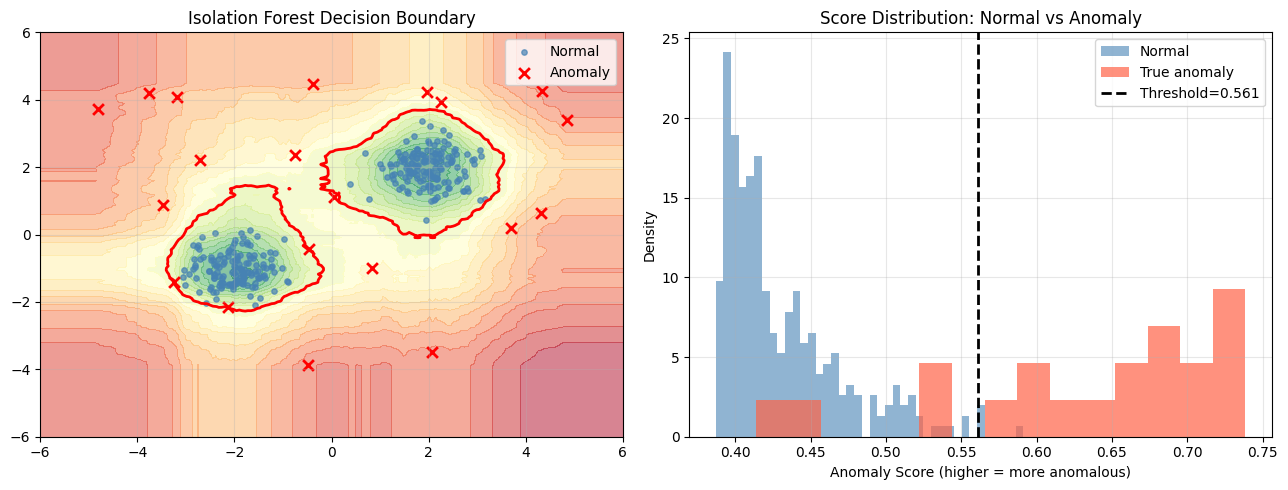

Precision: 0.800
Recall:    0.800
AUC-ROC:   0.957


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

# Generate dataset: two normal clusters + scattered anomalies
X_c1 = np.random.randn(150, 2) * 0.5 + [2, 2]
X_c2 = np.random.randn(150, 2) * 0.5 + [-2, -1]
X_anom = np.random.uniform(-5, 5, (20, 2))
X_all = np.vstack([X_c1, X_c2, X_anom])
y_true_if = np.array([0]*300 + [1]*20)

# Fit Isolation Forest
iso = IsolationForest(n_estimators=200, contamination=0.06, random_state=42, n_jobs=-1)
labels = iso.fit_predict(X_all)  # 1=normal, -1=anomaly
scores = -iso.score_samples(X_all)  # higher = more anomalous

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: decision boundary contour
ax = axes[0]
xx, yy = np.meshgrid(np.linspace(-6, 6, 200), np.linspace(-6, 6, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = -iso.score_samples(grid).reshape(xx.shape)
ax.contourf(xx, yy, Z, levels=20, cmap='RdYlGn_r', alpha=0.5)
ax.contour(xx, yy, Z, levels=[np.percentile(scores, 94)], colors='red', linewidths=2)
ax.scatter(X_all[labels==1, 0], X_all[labels==1, 1], c='steelblue', s=15, alpha=0.7, label='Normal')
ax.scatter(X_all[labels==-1, 0], X_all[labels==-1, 1], c='red', s=60, marker='x', lw=2, label='Anomaly')
ax.set_title('Isolation Forest Decision Boundary', fontsize=12)
ax.legend(); ax.grid(True, alpha=0.3)

# Right: anomaly score histogram
ax2 = axes[1]
ax2.hist(scores[y_true_if==0], bins=40, alpha=0.6, color='steelblue', label='Normal', density=True)
ax2.hist(scores[y_true_if==1], bins=15, alpha=0.7, color='tomato', label='True anomaly', density=True)
threshold = np.percentile(scores, 94)
ax2.axvline(threshold, color='black', linestyle='--', lw=2, label=f'Threshold={threshold:.3f}')
ax2.set_xlabel('Anomaly Score (higher = more anomalous)')
ax2.set_ylabel('Density')
ax2.set_title('Score Distribution: Normal vs Anomaly')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('isolation_forest.png', dpi=120, bbox_inches='tight')
plt.show()

from sklearn.metrics import precision_score, recall_score, roc_auc_score
y_pred = (labels == -1).astype(int)
print(f"Precision: {precision_score(y_true_if, y_pred):.3f}")
print(f"Recall:    {recall_score(y_true_if, y_pred):.3f}")
print(f"AUC-ROC:   {roc_auc_score(y_true_if, scores):.3f}")

---
## 6. Hyperparameters

### `n_estimators` (default: 100)

Number of isolation trees. More trees → more stable scores. Path lengths converge quickly; 100–200 is usually enough.

### `max_samples` (default: `'auto'` = 256)

Number of training points per tree. The key hyperparameter for Isolation Forest.
- **256 is optimal**: beyond 256, path lengths saturate — anomalies and normal points become indistinguishable
- Using all data often **hurts** performance

### `contamination`

Expected proportion of anomalies. Sets the decision threshold.
- If `'auto'`: threshold = 0.5 (theoretical cutoff from the paper)
- If a float (e.g., 0.05): threshold = the 95th percentile of anomaly scores
- Always tune this based on domain knowledge about expected anomaly rate

### `max_features` (default: 1.0)

Fraction of features used for each split. Lower values add randomness, can help with very high-dimensional data.

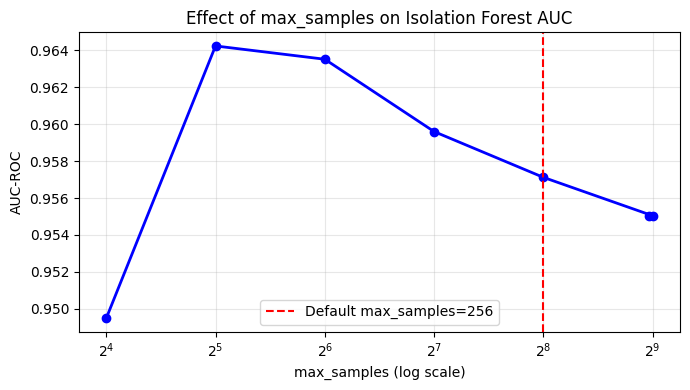

max_samples → AUC:
     16: 0.9495
     32: 0.9642
     64: 0.9635
    128: 0.9596
    256: 0.9571
    512: 0.9550
    500: 0.9550


In [3]:
# Effect of max_samples on Isolation Forest performance
from sklearn.metrics import roc_auc_score
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

np.random.seed(42)
n = 500
X_norm = np.random.randn(n, 2)
X_anm = np.random.uniform(-5, 5, (25, 2))
X_eval = np.vstack([X_norm, X_anm])
y_eval = np.array([0]*n + [1]*25)

sample_sizes = [16, 32, 64, 128, 256, 512, n]
aucs = []
for ms in sample_sizes:
    iso = IsolationForest(n_estimators=200, max_samples=min(ms, n), random_state=42)
    iso.fit(X_eval)
    s = -iso.score_samples(X_eval)
    aucs.append(roc_auc_score(y_eval, s))

plt.figure(figsize=(7, 4))
plt.plot(sample_sizes, aucs, 'bo-', lw=2)
plt.axvline(256, color='red', linestyle='--', label='Default max_samples=256')
plt.xscale('log', base=2)
plt.xlabel('max_samples (log scale)')
plt.ylabel('AUC-ROC')
plt.title('Effect of max_samples on Isolation Forest AUC')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('isolation_forest_max_samples.png', dpi=120, bbox_inches='tight')
plt.show()
print("max_samples → AUC:")
for ms, auc in zip(sample_sizes, aucs):
    print(f"  {ms:5d}: {auc:.4f}")

---
## 7. One-Class SVM

One-Class SVM (Schölkopf et al., 2001) learns a **boundary in feature space** that encloses most of the training data.

### Objective

$$\min_{\mathbf{w}, \rho, \xi} \quad \frac{1}{2}\|\mathbf{w}\|^2 + \frac{1}{\nu n} \sum_{i=1}^n \xi_i - \rho$$

subject to: $\mathbf{w}^T \phi(\mathbf{x}_i) \geq \rho - \xi_i$, $\xi_i \geq 0$

- $\nu \in (0, 1)$: upper bound on the fraction of outliers and lower bound on the fraction of support vectors
- $\phi(\mathbf{x})$: kernel mapping to higher-dimensional space
- $\rho$: the offset (learned threshold)

### Decision function

$$f(\mathbf{x}) = \text{sign}(\mathbf{w}^T\phi(\mathbf{x}) - \rho)$$

+1 = normal, −1 = anomaly

### When to Use One-Class SVM
- You have **only normal** training data (novelty detection setting)
- RBF kernel can detect non-spherical normal regions
- **Limitation**: $O(n^2)$ training — not scalable. Use Isolation Forest for large data.

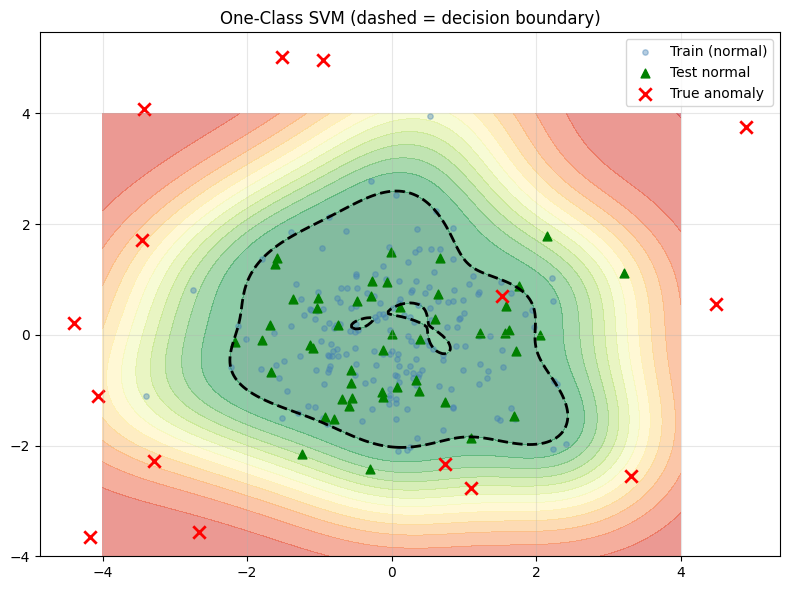

One-Class SVM — Precision: 0.636, Recall: 0.933


In [4]:
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
X_train_norm = np.random.randn(200, 2)  # normal training data only
X_test_norm = np.random.randn(50, 2)
X_test_anom = np.random.uniform(-5, 5, (15, 2))
X_test = np.vstack([X_test_norm, X_test_anom])
y_test = np.array([0]*50 + [1]*15)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train_norm)
X_test_s = scaler.transform(X_test)

oc_svm = OneClassSVM(nu=0.1, kernel='rbf', gamma='scale')
oc_svm.fit(X_train_s)
preds = oc_svm.predict(X_test_s)  # 1=normal, -1=anomaly
scores_svm = -oc_svm.decision_function(X_test_s)

# Visualize
fig, ax = plt.subplots(figsize=(8, 6))
xx, yy = np.meshgrid(np.linspace(-4, 4, 200), np.linspace(-4, 4, 200))
Z = oc_svm.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
ax.contourf(xx, yy, Z, levels=15, cmap='RdYlGn', alpha=0.5)
ax.contour(xx, yy, Z, levels=[0], colors='black', linewidths=2, linestyles='--')
ax.scatter(X_train_s[:, 0], X_train_s[:, 1], c='steelblue', s=15, alpha=0.4, label='Train (normal)')
ax.scatter(X_test_s[y_test==0, 0], X_test_s[y_test==0, 1], c='green', s=40, marker='^', label='Test normal')
ax.scatter(X_test_s[y_test==1, 0], X_test_s[y_test==1, 1], c='red', s=80, marker='x', lw=2, label='True anomaly')
ax.set_title('One-Class SVM (dashed = decision boundary)', fontsize=12)
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('one_class_svm.png', dpi=120, bbox_inches='tight')
plt.show()

from sklearn.metrics import precision_score, recall_score
y_pred_svm = (preds == -1).astype(int)
print(f"One-Class SVM — Precision: {precision_score(y_test, y_pred_svm):.3f}, Recall: {recall_score(y_test, y_pred_svm):.3f}")

---
## 8. Evaluating Anomaly Detectors

### Why Standard Accuracy Fails

If 1% of data is anomalous, a model that always predicts "normal" has 99% accuracy. Accuracy is useless here.

### AUC-ROC

Area under the ROC curve (TPR vs FPR). Range [0, 1]; 0.5 = random, 1.0 = perfect.

**Problem**: In extreme imbalance (0.1% anomalies), a model can have high AUC-ROC while being terrible on the minority class.

### AUC-PR (Average Precision) ← Preferred

Area under the Precision-Recall curve. Focuses on the minority class. Much more informative for anomaly detection.

### Threshold-Based Metrics

Set a threshold on the anomaly score to produce binary labels:
- **Precision**: of the points I flagged, how many are actually anomalies?
- **Recall**: of the actual anomalies, how many did I catch?
- **F1**: harmonic mean of precision and recall

**Trade-off**: Lowering the threshold → more anomalies flagged → higher recall, lower precision. Set the threshold based on the cost of false alarms vs missed anomalies in your domain.

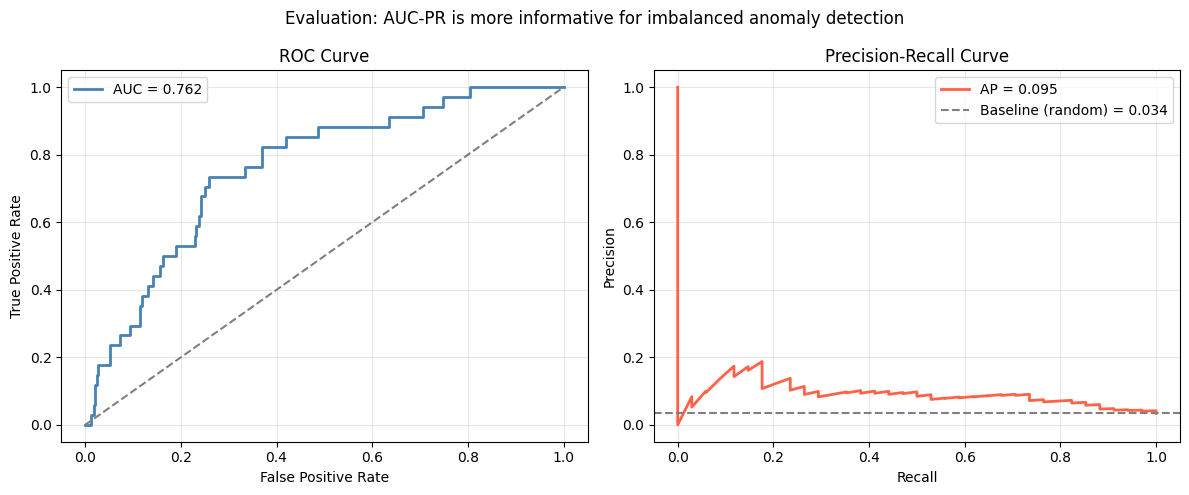

AUC-ROC: 0.7622
AUC-PR:  0.0948  (vs random baseline = 0.0340)


In [5]:
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             precision_recall_curve, roc_curve)
from sklearn.ensemble import IsolationForest
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(0)
X_ev, y_ev = make_classification(n_samples=1000, n_features=10, n_informative=5,
                                  weights=[0.97, 0.03], random_state=42)

iso_eval = IsolationForest(n_estimators=200, contamination=0.03, random_state=42)
iso_eval.fit(X_ev)
scores_ev = -iso_eval.score_samples(X_ev)

auc_roc = roc_auc_score(y_ev, scores_ev)
auc_pr = average_precision_score(y_ev, scores_ev)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fpr, tpr, _ = roc_curve(y_ev, scores_ev)
axes[0].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc_roc:.3f}')
axes[0].plot([0,1],[0,1],'--', color='gray')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

prec, rec, _ = precision_recall_curve(y_ev, scores_ev)
axes[1].plot(rec, prec, color='tomato', lw=2, label=f'AP = {auc_pr:.3f}')
axes[1].axhline(y_ev.mean(), color='gray', linestyle='--', label=f'Baseline (random) = {y_ev.mean():.3f}')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Evaluation: AUC-PR is more informative for imbalanced anomaly detection', fontsize=12)
plt.tight_layout()
plt.savefig('anomaly_evaluation.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"AUC-ROC: {auc_roc:.4f}")
print(f"AUC-PR:  {auc_pr:.4f}  (vs random baseline = {y_ev.mean():.4f})")

---
## 9. Full Implementation and Comparison

In [6]:
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.covariance import MinCovDet
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.datasets import load_breast_cancer
from scipy.stats import chi2
import numpy as np

# Use breast cancer: class 1 (malignant) = "anomaly", class 0 (benign) = "normal"
cancer = load_breast_cancer()
X_bc = StandardScaler().fit_transform(cancer.data)
y_bc = cancer.target  # 0=malignant (anomaly), 1=benign (normal)
y_bc_anom = 1 - y_bc  # 1=anomaly, 0=normal (malignant is anomalous)

# Split: train only on "normal" (benign) samples
normal_mask = y_bc == 1
X_train_bc = X_bc[normal_mask]

# 1. Isolation Forest
iso_bc = IsolationForest(n_estimators=200, contamination=0.37, random_state=42)
iso_bc.fit(X_train_bc)
scores_iso = -iso_bc.score_samples(X_bc)

# 2. One-Class SVM
oc_bc = OneClassSVM(nu=0.1, kernel='rbf', gamma='scale')
oc_bc.fit(X_train_bc)
scores_oc = -oc_bc.decision_function(X_bc)

# 3. Mahalanobis (MCD)
mcd_bc = MinCovDet(random_state=42).fit(X_train_bc)
scores_mah = mcd_bc.mahalanobis(X_bc)

print(f"{'Method':<22} {'AUC-ROC':>9} {'AUC-PR':>9}")
print('-' * 42)
for name, scores in [('Isolation Forest', scores_iso),
                      ('One-Class SVM', scores_oc),
                      ('Mahalanobis (MCD)', scores_mah)]:
    roc = roc_auc_score(y_bc_anom, scores)
    pr = average_precision_score(y_bc_anom, scores)
    print(f"{name:<22} {roc:>9.4f} {pr:>9.4f}")

Method                   AUC-ROC    AUC-PR
------------------------------------------
Isolation Forest          0.9645    0.9362
One-Class SVM             0.9671    0.9585
Mahalanobis (MCD)         0.9341    0.8744


---
## 10. When to Use Which Method

| Method | Best For | Avoid When |
|---|---|---|
| **Z-Score / IQR** | 1D/2D, Gaussian data, quick baseline | Multivariate, non-Gaussian |
| **Mahalanobis** | Correlated multivariate features, Gaussian assumption | Non-linear anomaly patterns |
| **Isolation Forest** | Large datasets, high-dim, general-purpose | When local density patterns matter |
| **One-Class SVM** | Only normal training data, small datasets | Large n ($>$10K points) |
| **LOF** | Varying-density clusters, local outliers | High-dim ($>$20 features) |
| **DBSCAN** | Spatial/clustered data, unknown K | Very high-dim, needs tuning |

### Recommended Workflow

```
1. Always start with IQR/Z-score (per feature) as a sanity check
2. Fit Isolation Forest — works well for most tabular problems
3. If data has local density structure → try LOF
4. If you only have normal data → try One-Class SVM or Isolation Forest (semi-supervised mode)
5. Evaluate with AUC-PR, not accuracy
6. Use domain knowledge to set the threshold (contamination parameter)
```

### sklearn Quick Reference
```python
from sklearn.ensemble import IsolationForest

iso = IsolationForest(n_estimators=200, contamination=0.05, random_state=42)
iso.fit(X_train)                          # or fit on normal data only
labels = iso.predict(X_test)              # 1=normal, -1=anomaly
scores = -iso.score_samples(X_test)       # higher = more anomalous
```